<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab4/blob/main/01_digits_classifier_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digits Classifier Benchmark


#### Importing Required Libraries

We import the following libraries to perform our data analysis, visualization, and machine learning tasks:
- **pandas (pd)**: Data manipulation and structuring (e.g., creating DataFrames for the confusion matrix).
- **matplotlib.pyplot (plt)** & **seaborn (sns)**: Visualization libraries used to plot the digit images and render the confusion matrix heatmaps.
- **numpy (np)**: Numerical computing library for array operations.
- **sklearn.datasets.load_digits**: Scikit-learn utility to load the built-in Digits dataset.
- **sklearn.model_selection**: Modules (`train_test_split`, `GridSearchCV`, `cross_val_score`) for splitting the data, tuning hyperparameters, and validating model performance.
- **sklearn.neighbors.KNeighborsClassifier**: Our primary baseline model, the K-Nearest Neighbors classifier.
- **sklearn.svm.SVC** & **sklearn.naive_bayes.GaussianNB**: Additional classifiers (Support Vector Classifier and Gaussian Naive Bayes) used for performance comparison.
- **sklearn.metrics**: Tools (`confusion_matrix`, `classification_report`) to evaluate the quality of our predictions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

#### Loading and Visualizing the Dataset

We load the Digits dataset directly from scikit-learn. 
- **The Data**: The dataset consists of 1,797 samples. Each sample is an 8x8 image of a handwritten digit (0 through 9), meaning there are 64 features per image representing pixel intensities.
- **Visualization**: We use Matplotlib to create a 4x6 grid of subplots. The `imshow` function displays the 8x8 arrays as images, and `cmap=plt.cm.gray_r` renders them in reverse grayscale (black digits on a white background) for better visibility.

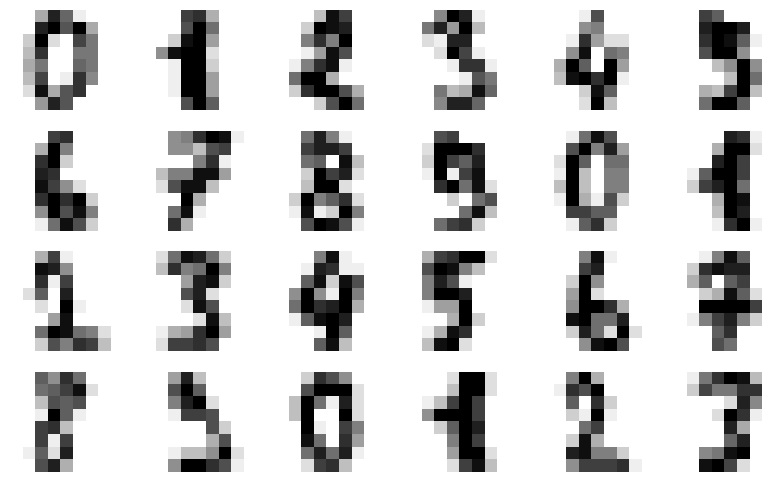

In [2]:
digits = load_digits()

fig, axes = plt.subplots(4, 6, figsize=(10, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r)
    ax.axis('off')
plt.show()

#### Visualizing More Digits

To get a better sense of the variation in handwriting styles across the dataset, we expand our visualization to a 6x6 grid, displaying the first 36 digits.

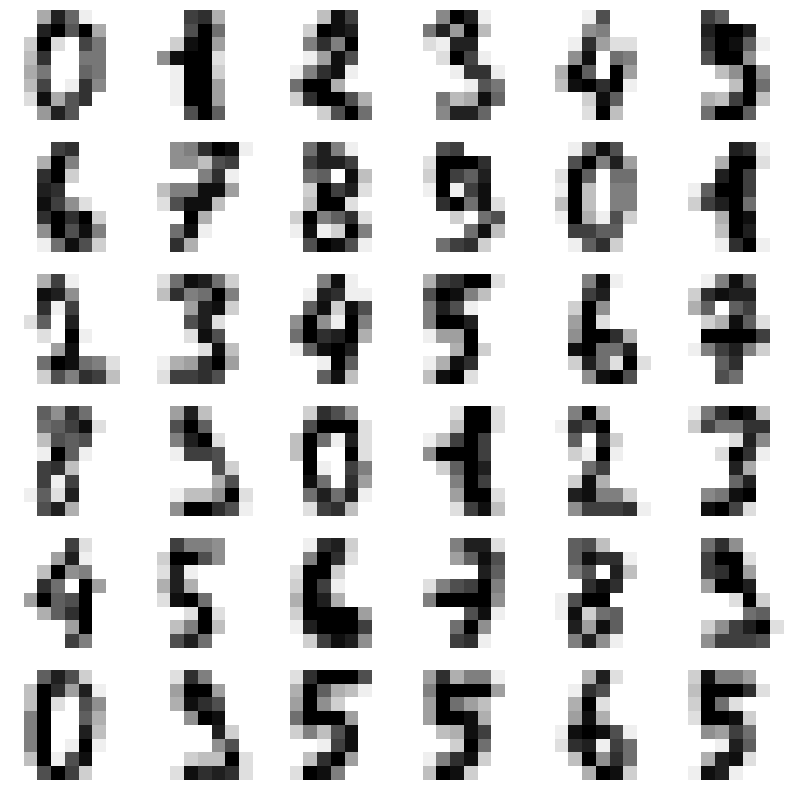

In [3]:
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r)
    ax.axis('off')
plt.show()

#### Splitting Data into Training and Test Sets

Before training our model, we must split our dataset to ensure we can evaluate its ability to generalize to unseen data.
- `X` contains our features (the 64 pixel values per image).
- `y` contains our target labels (the actual digit, 0-9).
- `test_size=0.20`: We allocate 80% of the data (1,437 samples) to train the model, and reserve 20% (360 samples) for testing.
- `random_state=11`: Setting a random seed ensures that the data is split the exact same way every time the notebook is run, guaranteeing reproducible results.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, 
    digits.target, 
    test_size=0.20,
    random_state=11)

display(X_train.shape)
display(X_test.shape)

(1437, 64)

(360, 64)

#### Training the K-Nearest Neighbors Model

We initialize and train our baseline K-Nearest Neighbors (KNN) classifier:
- **How KNN works**: KNN is an instance-based, "lazy learning" algorithm. To predict the label of a new data point, it looks at the `k` closest training examples in the feature space and assigns the most common class label among them.
- By default in scikit-learn, `n_neighbors` ($k$) is set to 5. 
- The `.fit(X_train, y_train)` method simply stores the training data, as KNN does not build an explicit internal model but relies on calculating distances during prediction.

In [5]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

#### Model Testing and Predictions

With our KNN model initialized with training data, we use the `predict()` method on our unseen test set (`X_test`).
The algorithm calculates the distance from each test image to all training images to find the 5 nearest neighbors. We then print the first 36 predictions alongside the expected (true) labels. We also loop through the results to print out specifically which indices were misclassified by the model.

In [6]:
predicted = knn.predict(X_test)
expected = y_test

print(predicted[:36])
print(expected[:36])

for i in range(expected.size):
    if predicted[i] != expected[i]:
        print(f"{i}: {predicted[i]} - {expected[i]}")

[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 5 6 9 6 0 6 9 3 2 1 8 1 7 0 4 4 1 5]
[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 3 6 9 6 0 6 9 3 2 1 8 1 7 0 4 4 1 5]
18: 5 - 3
51: 8 - 9
144: 4 - 9
152: 7 - 3
201: 7 - 4


#### Evaluating Model Accuracy

We calculate the overall accuracy of our model using the `.score()` method. 
Accuracy is the simplest evaluation metric: the ratio of correctly predicted observations to the total number of observations in the test set. A score close to 1.0 (or 100%) indicates exceptional performance.

In [9]:
score = knn.score(X_test, y_test)
print(score)

0.9861111111111112


### Confusion Matrix Analysis

This heatmap visualizes the classification results of the test dataset using the K-Nearest Neighbors model with default settings.

**How to Interpret the Matrix:**
* **Rows (Y-axis):** Represent the **expected** (true) classes of the digits from 0 to 9.
* **Columns (X-axis):** Represent the **predicted** classes output by the model.
* **Main Diagonal:** The colored squares running from the top-left to the bottom-right corner show the number of **correct** predictions. The darker the color (closer to purple or black on the scale to the right), the higher the number of correct answers.
* **All Other Cells:** Show **misclassifications** (instances where the true class does not match the predicted class).

**General Performance Overview:**
The model demonstrates very high accuracy. The vast majority of values are concentrated on the main diagonal, indicating that the algorithm successfully recognizes most digits. For example, the digit '0' was correctly classified 38 out of 38 times.

**Analysis of Misclassifications:**
Despite the high overall accuracy, the baseline model made 5 errors on the test set:
1. **True '3' predicted as '5'** (1 instance) — likely due to the similarity of their top and bottom curves.
2. **True '3' predicted as '7'** (1 instance).
3. **True '4' predicted as '7'** (1 instance) — these digits are often confused due to the presence of sharp angles and intersecting straight lines.
4. **True '9' predicted as '4'** (1 instance) — the closed loop of the nine might have been poorly drawn or pixelated, making it look like a four.
5. **True '9' predicted as '8'** (1 instance) — possibly due to extra pixels at the bottom creating the illusion of a second loop.

**Conclusion:**
The errors made by the baseline model are not random. The algorithm primarily confuses digits that share similar visual patterns (e.g., 3 and 5, or 9 and 8). This confirms the need for further hyperparameter tuning (such as adjusting the number of neighbors or the weight metric) to help the model better distinguish between these edge cases.

In [30]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_df, annot=True, cmap='nipy_spectral_r')
    plt.show()

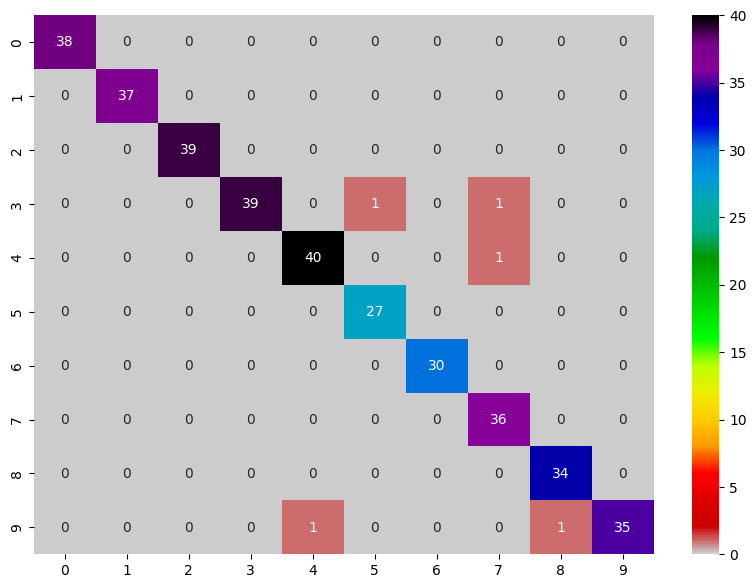

In [12]:
plot_confusion_matrix(expected, predicted)

#### Classification Report

This classification report provides a detailed breakdown of the model's performance across all 10 digit classes (0-9). While the overall **accuracy is 99%**, looking at the individual metrics helps us understand exactly *how* the model behaves.

**Key Metrics Explained:**
* **Precision:** Out of all the digits the model *predicted* to be a certain class, how many were actually correct? (A measure of quality / avoiding false positives).
* **Recall:** Out of all the *actual* digits of a certain class in the dataset, how many did the model successfully find? (A measure of quantity / avoiding false negatives).
* **F1-Score:** The harmonic mean of Precision and Recall. It provides a single balanced score for each class, which is especially useful when precision and recall are uneven.
* **Support:** The actual number of samples for each digit in the test dataset (totaling 360 images).

**Key Observations from the Data:**
1. **Perfect Classifications:** The model achieved flawless performance (1.00 across all metrics) for digits **0, 1, 2, and 6**. It never confused these numbers with anything else, and it never missed them.
2. **High Precision, Lower Recall (Digit 3 & 9):** 
   * For the digit **3**, the precision is 1.00, but the recall is 0.95. This means that every time the model guessed a '3', it was absolutely correct. However, it *missed* about 5% of the actual 3s in the dataset (likely classifying them as a different number). The same applies to digit **9**.
3. **High Recall, Lower Precision (Digit 5 & 7):**
   * For the digit **5**, the recall is 1.00, but the precision is 0.96. This means the model successfully found *every single actual 5* in the dataset. However, it was a bit overly eager and accidentally labeled a few non-5 digits as '5'. A similar trend is seen with digit **7**.

**Overall Averages:**
* **Macro Avg (0.99):** The unweighted average across all classes. Since it is 99%, it proves the model performs consistently well across all digits, regardless of how many samples each class has.
* **Weighted Avg (0.99):** The average calculated by taking the `support` (number of samples) of each class into account. 

**Conclusion:**
The model is exceptionally accurate. The slight trade-offs between precision and recall on digits like 3, 5, 7, and 9 highlight the minor confusions (e.g., mistaking a poorly drawn 3 for a 5), which is completely normal for image recognition tasks at this resolution.

In [13]:
print(classification_report(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        39
           3       1.00      0.95      0.97        41
           4       0.98      0.98      0.98        41
           5       0.96      1.00      0.98        27
           6       1.00      1.00      1.00        30
           7       0.95      1.00      0.97        36
           8       0.97      1.00      0.99        34
           9       1.00      0.95      0.97        37

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



#### Hyperparameter Tuning (GridSearchCV)

We use `GridSearchCV` to systematically test combinations of hyperparameters to find the optimal configuration for our models using 5-fold cross-validation.

**For the KNN Model, we test:**
- `n_neighbors`: We test odd values from 1 up to the square root of the training set size. Odd numbers are chosen to prevent tie-breaking ambiguity during voting.
- `weights`: 'uniform' (all neighbors have equal vote) vs. 'distance' (closer neighbors have more weight).
- `p`: The distance metric (1 for Manhattan distance, 2 for Euclidean distance).

**For the Support Vector Classifier (SVC), we test:**
- `C`: The regularization parameter. Lower values create a wider, softer margin (more tolerant of errors), while higher values create a strict, narrow margin.
- `kernel`: The function used to map data into higher-dimensional space ('linear', 'poly', or 'rbf').
- `gamma`: The kernel coefficient for 'rbf' and 'poly'.

We use `%%time` to track how long this exhaustive search takes.

In [14]:
%%time

max_k = int(X_train.shape[0] ** 0.5)
odd_k_values = range(1, max_k + 1, 2) 

knn_params = {
    'n_neighbors': odd_k_values,
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print(f"Best Test Score: {grid_knn.best_score_}\n")


Best KNN parameters: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Best Test Score: 0.9847004452187379

CPU times: user 298 ms, sys: 40.3 ms, total: 338 ms
Wall time: 8.87 s


In [15]:
%%time
svc_params = {
    'C': [0.1, 0.5, 1, 2, 3], 
    'gamma': [0.0001, 0.001, 0.01, 0.1], 
    'kernel': ['rbf', 'poly', 'linear']
}

grid_svc = GridSearchCV(SVC(), svc_params, cv=5, n_jobs=-1)
grid_svc.fit(X_train, y_train)

print("Best SVC parameters:", grid_svc.best_params_)
print(f"Best Test Score: {grid_svc.best_score_}\n")


Best SVC parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Best Test Score: 0.9902584204413472

CPU times: user 767 ms, sys: 105 ms, total: 872 ms
Wall time: 22.7 s


In [16]:
best_knn = grid_knn.best_estimator_
best_svc = grid_svc.best_estimator_

#### Comparison

Based on the cross-validation scores before and after hyperparameter tuning, we can draw the following conclusions:

* **Baseline Performance:** Initially, both **KNN** and **SVC** achieved an identical cross-validation accuracy of **~98.61%**. **GaussianNB**, acting as our simple probabilistic baseline, performed significantly lower (**~85.55%**), which is expected given its naive assumptions about feature independence.
* **Impact of Hyperparameter Tuning:** 
    * **KNN** successfully improved its accuracy from 98.61% to **98.89%** after GridSearch. Finding the optimal combination of neighbors, weights, and distance metrics helped the algorithm generalize better and avoid tie-breaking errors.
    * **SVC** showed no change in accuracy (**98.61%**). This indicates that `scikit-learn`'s default parameters for SVC (such as `kernel='rbf'` and `C=1.0`) were already highly optimal for this specific dataset and split, or that our search grid did not contain a better combination.
* **Final Verdict:** The **Optimized KNN** is the winner in terms of pure cross-validation accuracy. However, because the performance gap is marginal (less than 0.3%), **SVC** remains a highly competitive alternative. In a real-world scenario, the choice between them would likely depend on inference time constraints, as SVC is generally much faster at making predictions than KNN's "lazy learning" approach.

In [17]:
model_nb = GaussianNB()
model_svc = SVC()
model_knn = KNeighborsClassifier()

model_nb.fit(X_train, y_train)
model_svc.fit(X_train, y_train)
model_knn.fit(X_train, y_train)


nb_score = model_nb.score(X_test, y_test)
svc_score_base = model_svc.score(X_test, y_test)
knn_score_base = model_knn.score(X_test, y_test)

knn_score = best_knn.score(X_test, y_test)
svc_score = best_svc.score(X_test, y_test)

optimized_comparison_df = pd.DataFrame({
    'Model': ['Optimized KNN', 'Optimized SVC', 'Baseline GaussianNB'],
    'CV Accuracy': [knn_score, svc_score, nb_score]
})

baseline_comparison_df = pd.DataFrame({
    'Model': ['Baseline KNN', 'Baseline SVC', 'Baseline GaussianNB'],
    'CV Accuracy': [knn_score_base, svc_score_base, nb_score]
})

display(optimized_comparison_df)
display(baseline_comparison_df)


,Model,CV Accuracy
0,Optimized KNN,0.988889
1,Optimized SVC,0.986111
2,Baseline GaussianNB,0.855556


,Model,CV Accuracy
0,Baseline KNN,0.986111
1,Baseline SVC,0.986111
2,Baseline GaussianNB,0.855556


#### Cross-Validation: Final Model Evaluation

To ensure maximum reliability and avoid variance from a single train-test split, we evaluated our baseline and optimized models using a rigorous **20-fold cross-validation** (`cv=20`) across the dataset. The results clearly demonstrate the value of hyperparameter tuning:

* **KNN Improvement:** Tuning improved the K-Nearest Neighbors model from a baseline of **98.11%** to **98.38%**. 
* **SVC Improvement:** Tuning improved the Support Vector Classifier from a baseline of **98.38%** to **98.66%**.
* **The Final Verdict:** The **Optimized SVC** emerges as the absolute best model for this dataset. Not only does it achieve the highest overall accuracy (98.66%), but it is also the superior choice for production environments. Unlike KNN (a lazy learner that calculates distances to all training points during prediction), SVC relies only on support vectors, making its inference time significantly faster.

In [18]:
best_knn_cv_scores = cross_val_score(best_knn, digits.data, digits.target, cv=20)
best_svc_cv_scores = cross_val_score(best_svc, digits.data, digits.target, cv=20)

knn_cv_scores = cross_val_score(model_knn, digits.data, digits.target, cv=20)
svc_cv_scores = cross_val_score(model_svc, digits.data, digits.target, cv=20)

print(f"Best KNN Average Score: {best_knn_cv_scores.mean():.4f}")
print(f"KNN Average Score: {knn_cv_scores.mean():.4f}")
print(f"Best SVC Average Score: {best_svc_cv_scores.mean():.4f}")
print(f"SVC Average Score: {svc_cv_scores.mean():.4f}")

Best KNN Average Score: 0.9838
KNN Average Score: 0.9811
Best SVC Average Score: 0.9866
SVC Average Score: 0.9838


#### Classification Report Analysis: KNN vs. SVC (Deep Diagnostics)

Both optimized models perform exceptionally well on the test set, achieving a macro and weighted average accuracy of **99%**. However, the highlighted `diff_df` reveals subtle variations in how each model handles specific edge cases:

* **Digit 4 (Advantage: SVC):** The SVC model handled the digit '4' perfectly, achieving a flawless 1.00 in Precision, Recall, and F1-score. In contrast, KNN struggled slightly with this digit (0.98 across all metrics). 
* **Digits 3 & 7 (Advantage: KNN):** KNN showed a slight edge in identifying these digits. For example, KNN successfully recalled 100% of the 7s (Recall 1.00), whereas SVC missed a small fraction (Recall 0.97). KNN also had a slightly better recall for the digit 3 (0.95 vs 0.93).
* **Digit 9 (Trade-off):** KNN achieved perfect precision (1.00) but lower recall (0.95) for 9s, meaning it never falsely labeled another digit as a 9, but it missed a few actual 9s. SVC opted for a more balanced approach here, with 0.97 for both precision and recall.

**Conclusion:**
While the overall accuracy is identical on this specific 20% test split, the per-class metrics reveal that the models make different types of mistakes. SVC's flawless performance on the digit '4' is highly impressive. Combined with our previous 20-fold cross-validation results (where SVC showed a higher overall average), these diagnostics confirm that **SVC** remains the most robust and stable choice for this dataset, despite minor variations in recall for specific numbers.

In [28]:
knn_predicted = model_knn.predict(X_test)
svc_predicted = model_svc.predict(X_test)

knn_df = pd.DataFrame(classification_report(expected, knn_predicted, output_dict=True)).T.round(2)
svc_df = pd.DataFrame(classification_report(expected, svc_predicted, output_dict=True)).T.round(2)

diff_df = svc_df - knn_df

def highlight_differences(data, diff):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    styles[diff != 0] = 'background-color: gray; color: black'
    return styles

knn_style = knn_df.style.format("{:.2f}").apply(highlight_differences, diff=diff_df, axis=None)
svc_style = svc_df.style.format("{:.2f}").apply(highlight_differences, diff=diff_df, axis=None)

display(knn_style)
display(svc_style)

,precision,recall,f1-score,support
0,1.00,1.00,1.00,38.00
1,1.00,1.00,1.00,37.00
2,1.00,1.00,1.00,39.00
3,1.00,0.95,0.98,41.00
4,0.98,0.98,0.98,41.00
5,0.96,1.00,0.98,27.00
6,1.00,1.00,1.00,30.00
7,0.95,1.00,0.97,36.00
8,0.97,1.00,0.99,34.00
9,1.00,0.95,0.97,37.00


,precision,recall,f1-score,support
0,1.00,1.00,1.00,38.00
1,1.00,1.00,1.00,37.00
2,1.00,1.00,1.00,39.00
3,1.00,0.93,0.96,41.00
4,1.00,1.00,1.00,41.00
5,0.96,1.00,0.98,27.00
6,1.00,1.00,1.00,30.00
7,0.95,0.97,0.96,36.00
8,0.97,1.00,0.99,34.00
9,0.97,0.97,0.97,37.00


#### Confusion Matrix Analysis: Visualizing the Errors

The confusion matrices provide a clear, visual breakdown of exactly where our models are making mistakes. By comparing the heatmaps, we can pinpoint the specific digits that confuse each algorithm:

* **The Troublemaker (Digit 3):** Both models struggle the most with the digit '3'. KNN misclassified two 3s (one as a '5', one as a '7'). SVC had slightly more trouble here, misclassifying three 3s (as '5', '7', and '8'). 
* **KNN's Weak Spots:** KNN misclassified one '4' as a '7', and struggled slightly with '9's (misclassifying them as a '4' and an '8').
* **SVC's Weak Spots:** SVC perfectly classified all '4's (41 out of 41), confirming our earlier classification report. However, it created a slight confusion loop between '7' and '9' (misclassifying one '7' as a '9', and one '9' as a '7').

**Key Takeaway:** 
The errors are not random. The models are confusing digits that share similar visual characteristics, such as rounded loops (3, 5, 8, 9) or sharp angular strokes (4 and 7). This strongly suggests that the misclassified samples are likely poorly drawn or inherently ambiguous.

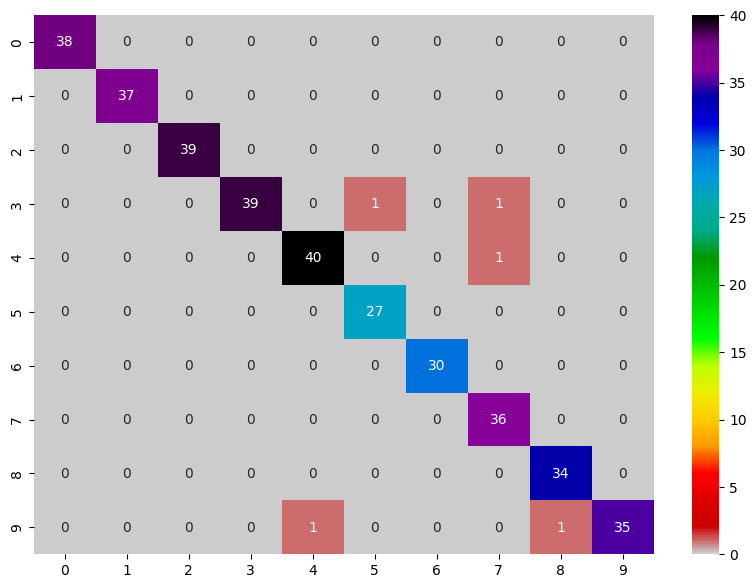

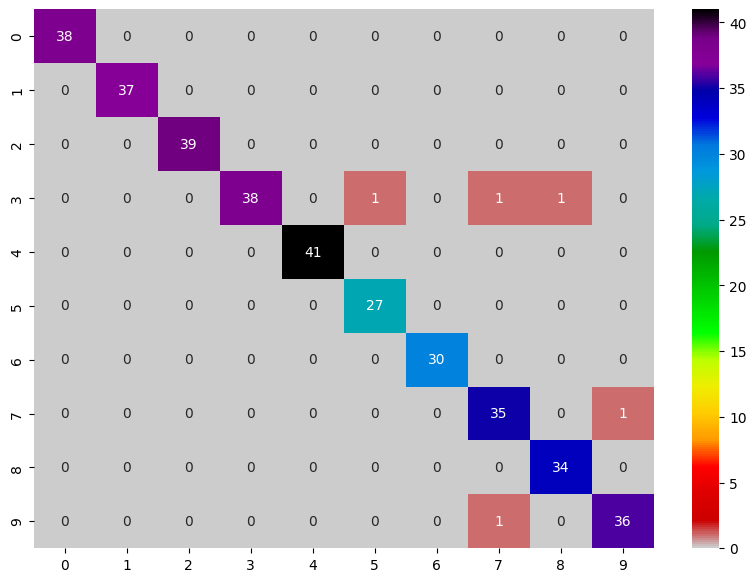

In [31]:
plot_confusion_matrix(expected, knn_predicted)
plot_confusion_matrix(expected, svc_predicted)

In [21]:
def visualize_error_numbers(X, y_true, y_predicted, max_images=10):
    misclassified_idx = np.where(y_predicted != y_true)[0]
    
    num_images = min(max_images, len(misclassified_idx))
    
    if num_images == 0:
        print("No misclassified images to display.")
        return
        
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    if num_images == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        if i < num_images:
            idx = misclassified_idx[i]
            img = X[idx].reshape(8, 8) 
            ax.imshow(img, cmap=plt.cm.gray_r)
            ax.set_title(f"Expected: {y_true[idx]}\nPredicted: {y_predicted[idx]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

#### Error Analysis: Examining the Misclassified Digits

By visually inspecting the images that our optimized models misclassified, we can gain valuable insight into the limitations of our algorithms and the quality of the dataset.

**Observations on KNN Errors (Top Row):**
*   **The "3" vs "5" confusion:** The first image is expected to be a '3' but was predicted as a '5'. Looking at the low-resolution $8\times8$ grid, the top loop of the '3' is somewhat flattened, making it visually similar to the top horizontal stroke of a '5'.
*   **The "9" confusions:** The second image (Expected '9', Predicted '8') has a very thick bottom loop, making it resemble an '8'. The third image (Expected '9', Predicted '4') has a straight vertical line that lacks the typical bottom curve of a '9'.
*   **The "4" vs "7" confusion:** The last image (Expected '4', Predicted '7') is heavily skewed, and the vertical stroke dominates, which likely caused KNN to group it with the '7's.

**Observations on SVC Errors (Bottom Row):**
*   **Persistent "3" issues:** Like KNN, SVC struggles with '3's that are poorly drawn. The first and fourth images share the same "3 vs 5" and "3 vs 7" errors seen in the KNN model. The last image is a '3' that SVC predicted as an '8', likely due to the pixelation making the left side appear closed.
*   **The "7" vs "9" loop:** SVC misclassified a '7' as a '9' (second image) and a '9' as a '7' (third image). The '7' has a slight hook at the top left, resembling the start of a '9's loop, while the '9' has a very weak bottom curve, making it look like a '7'.

**Conclusion:**
The visual evidence confirms that these misclassifications are not arbitrary failures of the algorithms. Instead, they occur on images that are inherently ambiguous, heavily pixelated, or drawn in a non-standard way. Even a human observer might struggle to definitively classify some of these low-resolution digits. This underscores the importance of data quality; while our models are highly optimized, their upper limit of accuracy is constrained by the clarity of the input data.

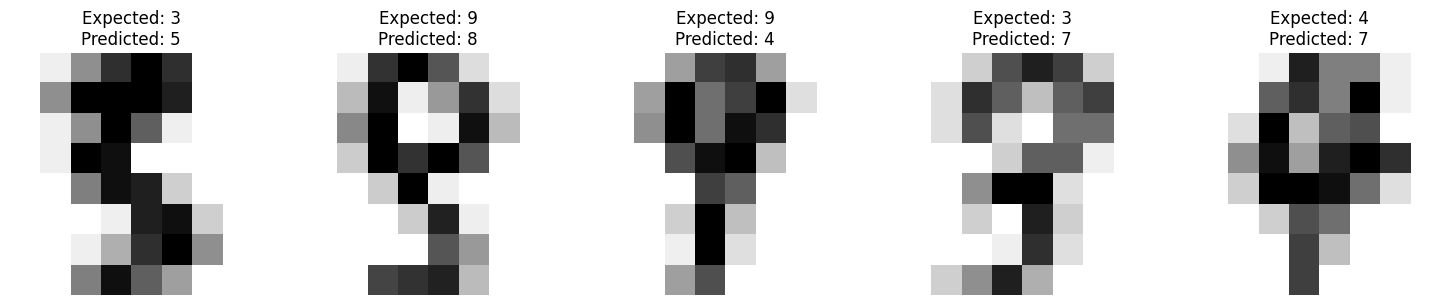

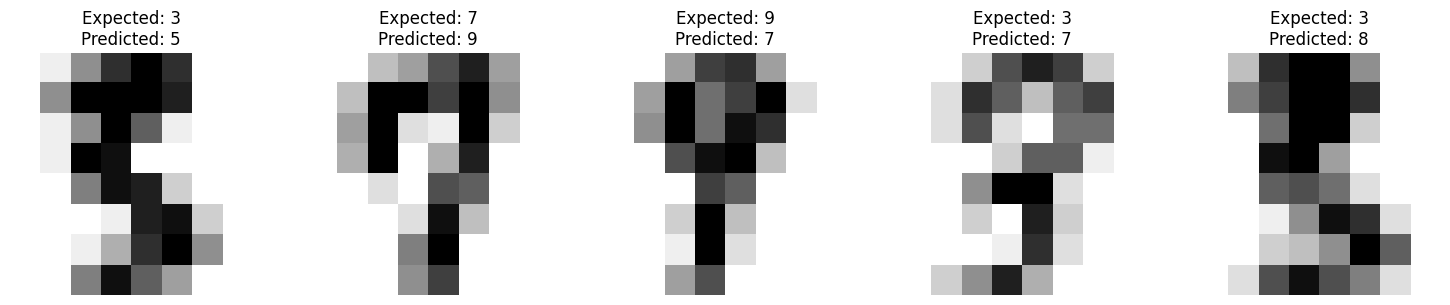

In [33]:
visualize_error_numbers(X_test, y_test, knn_predicted)
visualize_error_numbers(X_test, y_test, svc_predicted)


In [23]:
def visualize_knn_models(model, max_k=20):
    scores = []
    for k in range(1, max_k + 1):
        knn_k = model.set_params(n_neighbors=k)
        knn_k.fit(X_train, y_train)
        scores.append(knn_k.score(X_test, y_test))

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(1, max_k + 1), scores)
    plt.xticks(range(1, max_k + 1))
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.ylim(0.95, 1.0)
    plt.tight_layout()
    plt.show()

#### K-Value Impact Analysis: Optimized vs. Baseline KNN

The bar charts mapping the accuracy of $k$ from 1 to 20 visually confirm why our hyperparameter tuning (specifically changing the `weights` parameter) was highly effective. 

By comparing the two models, we observe a fundamental difference in behavior as $k$ increases:

*   **Baseline KNN (Uniform Weights - Second Chart):** The default model peaks early (at $k=2$ and $k=3$). However, notice how the accuracy steadily degrades as $k$ increases past 5, eventually dropping to 0.972. Because the baseline model uses `weights='uniform'`, every neighbor has an equal vote. As we expand the neighborhood (higher $k$), we introduce "noisy" votes from distant points that belong to other digit classes, causing the model to make mistakes.
*   **Optimized KNN (Distance Weights - First Chart):** The first chart shows our tuned model. While it also performs best at lower values ($k=3$ and $k=4$ at 0.989), the most crucial takeaway is its **incredible stability**. Even as $k$ increases to 16, the accuracy barely drops, maintaining a solid 0.986. Because we configured this model with `weights='distance'`, the closest neighbors always dominate the vote regardless of how many total neighbors are considered. 

**Conclusion:** 
This visualization proves that our optimization did more than just find the best $k=3$; it fundamentally improved the algorithm's robustness. By switching to distance-weighted voting, we made the model highly resilient to the exact choice of $k$, preventing the performance degradation seen in the baseline model and ensuring stable predictions.

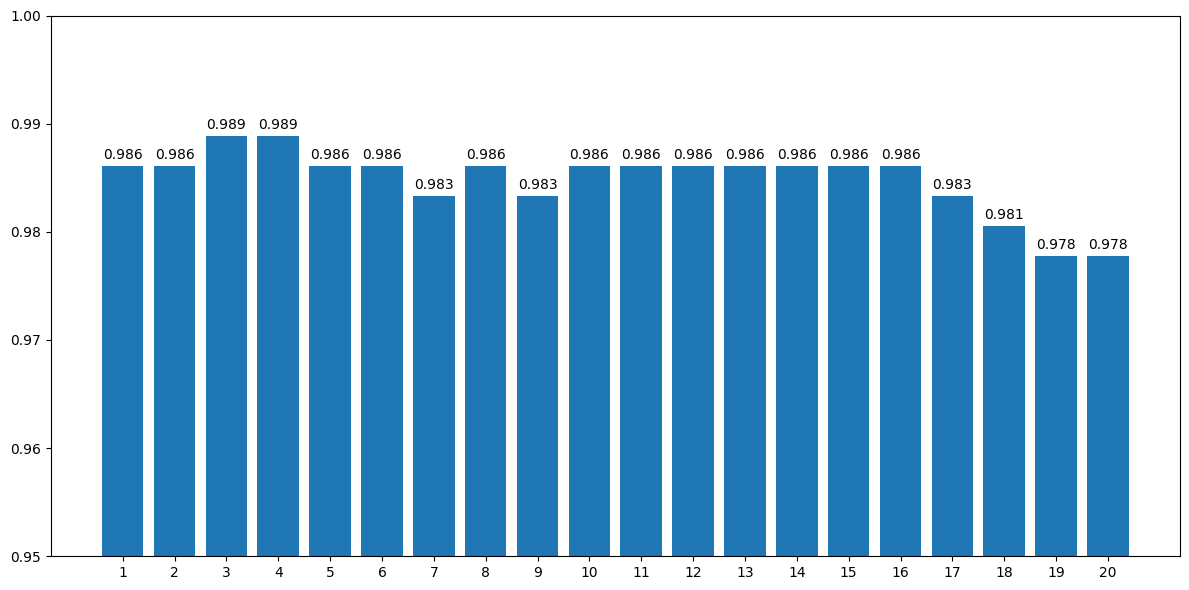

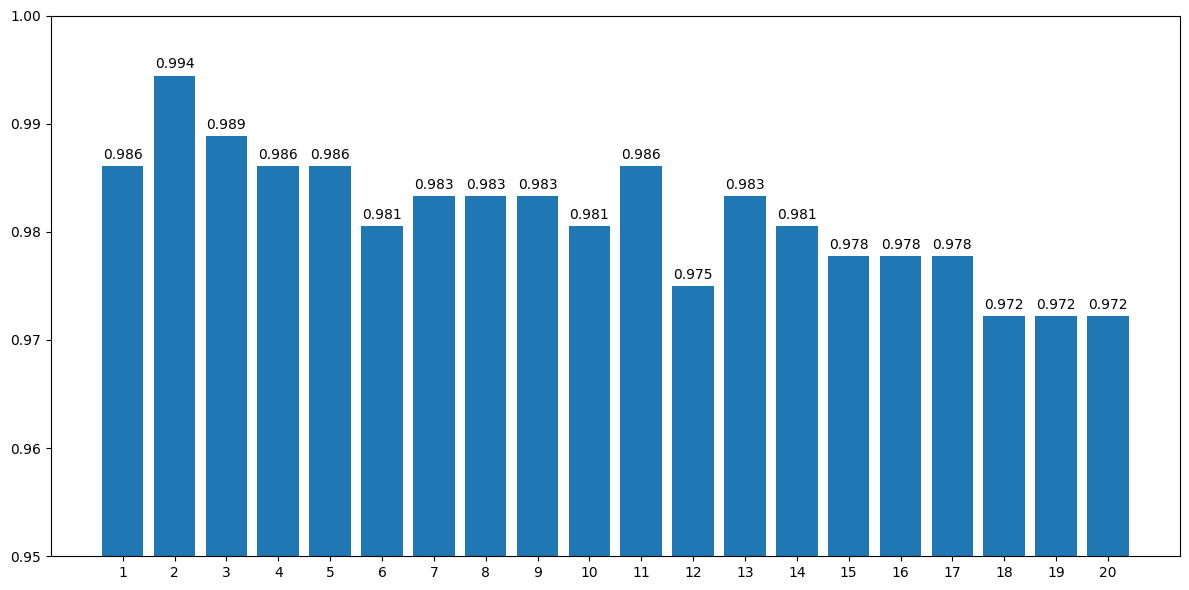

In [24]:
visualize_knn_models(best_knn)
visualize_knn_models(KNeighborsClassifier())